Data Cleaning

In [24]:
import pandas as pd

df = pd.read_csv("data/superstore.csv")

# Convert date
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# Drop missing
df = df.dropna()

print(df.head())

   Row ID        Order ID Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156 2017-11-08  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156 2017-11-08  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688 2017-06-12  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966 2016-10-11  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966 2016-10-11  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Category 

Feature Engineering

In [25]:
# Total spending per customer
customer_data = df.groupby('Customer ID').agg({
    'Sales': 'sum',
    'Order ID': 'count'
}).reset_index()

customer_data.columns = ['Customer ID', 'Total_Spend', 'Frequency']

print(customer_data.head())

  Customer ID  Total_Spend  Frequency
0    AA-10315     5563.560         11
1    AA-10375     1056.390         15
2    AA-10480     1790.512         12
3    AA-10645     5086.935         18
4    AB-10015      886.156          6


CUSTOMER SEGMENTATION

In [26]:
from sklearn.cluster import KMeans

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
customer_data['Cluster'] = kmeans.fit_predict(customer_data[['Total_Spend','Frequency']])

print(customer_data.head())

  Customer ID  Total_Spend  Frequency  Cluster
0    AA-10315     5563.560         11        1
1    AA-10375     1056.390         15        0
2    AA-10480     1790.512         12        0
3    AA-10645     5086.935         18        1
4    AB-10015      886.156          6        0


Visualize Clusters

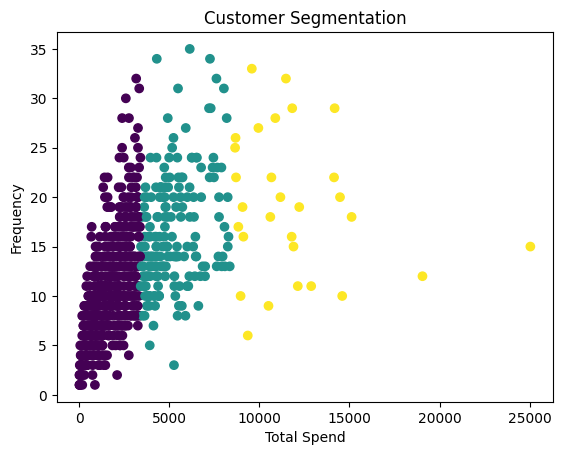

In [27]:
import matplotlib.pyplot as plt

plt.scatter(customer_data['Total_Spend'], customer_data['Frequency'], c=customer_data['Cluster'])
plt.xlabel("Total Spend")
plt.ylabel("Frequency")
plt.title("Customer Segmentation")
plt.show()

SALES PREDICTION

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Convert date to numeric (VERY IMPORTANT)
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

# Features
X = df[['Year', 'Month']]
y = df['Sales']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Model trained successfully")
print("MSE:", mse)
print("R2 Score:", r2)

Model trained successfully
MSE: 490055.27817621344
R2 Score: -0.0018840395210675265


In [29]:
df['Day'] = df['Order Date'].dt.day

X = df[['Year', 'Month', 'Day']]

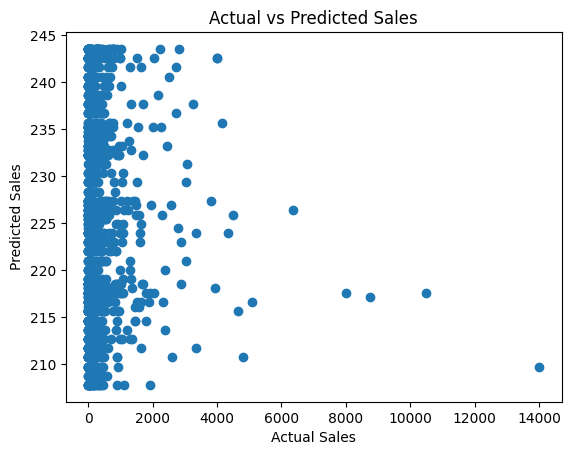

In [30]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

Save Data for Power BI

In [31]:
customer_data.to_csv("customer_segments.csv", index=False)
df.to_csv("cleaned_sales.csv", index=False)